<a href="https://colab.research.google.com/github/karenrosas0410-pixel/Estad-stica-2026B-/blob/main/Practica_2_U3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from numpy.polynomial.polynomial import Polynomial
from scipy.fftpack import fft, ifft

In [3]:
#Descargar datos de Tesla de los últimos 3 años
df = yf.download(
    "TSLA",
    period="3y",
    interval="1d"
)

#Reiniciar los índices
df.reset_index(inplace=True)

#Mostrar las primeras filas
df.head()

/tmp/ipykernel_2733/3404516467.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2023-06-12,249.830002,250.970001,244.589996,247.940002,150337900
1,2023-06-13,258.709991,259.679993,251.339996,253.509995,162384300
2,2023-06-14,256.790009,261.570007,250.500000,260.170013,170575500
3,2023-06-15,255.899994,258.950012,247.289993,248.399994,160171200
4,2023-06-16,260.540009,263.600006,257.209991,258.920013,167915600


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 752 entries, 0 to 751
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        752 non-null    datetime64[ns]
 1   (Close, TSLA)   752 non-null    float64       
 2   (High, TSLA)    752 non-null    float64       
 3   (Low, TSLA)     752 non-null    float64       
 4   (Open, TSLA)    752 non-null    float64       
 5   (Volume, TSLA)  752 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 35.4 KB


In [5]:
#Ver nombres de columnas
print(df.columns)

#Usar Close como precio ajustado
df= df[["Date", "Close"]]

#Cambiar nombres
df.columns= ["Fecha", "Adj_Close_TSLA"]

df.head()

MultiIndex([(  'Date',     ''),
            ( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])


,Fecha,Adj_Close_TSLA
0,2023-06-12,249.830002
1,2023-06-13,258.709991
2,2023-06-14,256.790009
3,2023-06-15,255.899994
4,2023-06-16,260.540009


In [6]:
df["Fecha"]= pd.to_datetime(df["Fecha"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 752 entries, 0 to 751
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Fecha           752 non-null    datetime64[ns]
 1   Adj_Close_TSLA  752 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.9 KB


In [7]:
x= df["Fecha"]
y= df["Adj_Close_TSLA"]

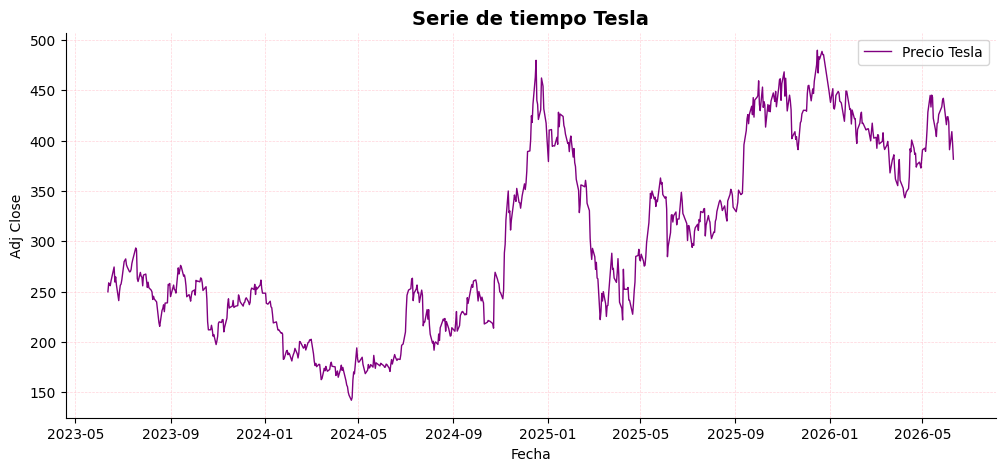

In [10]:
plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    y,
    color="purple",
    linewidth=1,
    label="Precio Tesla"
)

plt.title("Serie de tiempo Tesla", fontsize=14, fontweight="bold")

plt.xlabel("Fecha", fontsize=10)
plt.ylabel("Adj Close", fontsize=10)

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.7,
    color="pink"
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.margins(x=0.05, y=0.05)

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.legend(fontsize=10, loc='best', frameon=True)

plt.show()

In [11]:
# Convertir fechas a timestamp
X = pd.to_datetime(df["Fecha"]).map(pd.Timestamp.timestamp)

# Grado del polinomio
grado = 5

# Modelo polinomial
modelo= Polynomial.fit(X, y, deg=grado)

# Tendencia estimada
df["tendencia_polinomial"] = modelo(X)

# Residuales iniciales
df["ruido_polinomial"] = (
    df["Adj_Close_TSLA"]
    - df["tendencia_polinomial"]
)

df.head()

,Fecha,Adj_Close_TSLA,tendencia_polinomial,ruido_polinomial
0,2023-06-12,249.830002,292.689045,-42.859043
1,2023-06-13,258.709991,291.947358,-33.237367
2,2023-06-14,256.790009,291.208946,-34.418938
3,2023-06-15,255.899994,290.473808,-34.573814
4,2023-06-16,260.540009,289.741942,-29.201933


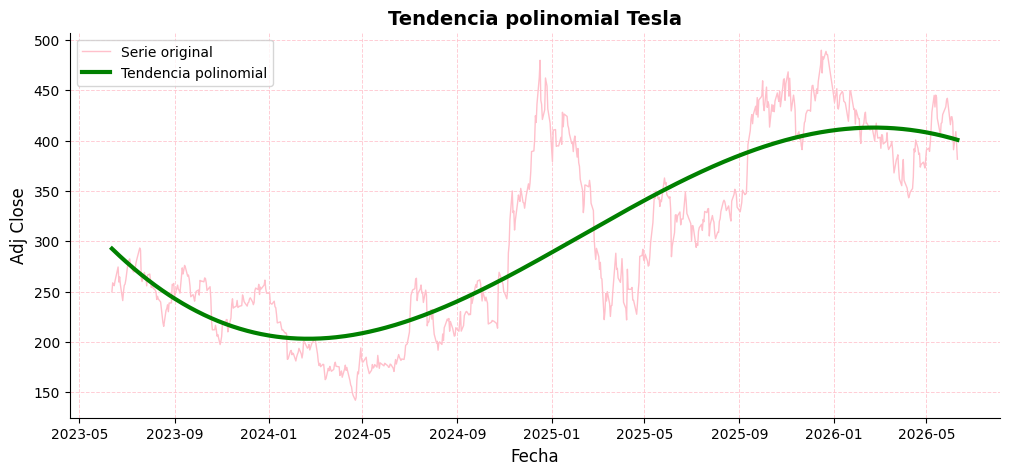

In [13]:
plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    y,
    color="pink",
    linewidth=1,
    label="Serie original"
)

plt.plot(
    x,
    df["tendencia_polinomial"],
    color="green",
    linewidth=3,
    label="Tendencia polinomial"
)

plt.title("Tendencia polinomial Tesla", fontsize=14, fontweight="bold")

plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Adj Close", fontsize=12)

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
    color="pink"
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.margins(x=0.05, y=0.05)

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.legend(fontsize=10, loc='best', frameon=True)

plt.show()

In [14]:
def Transformada_de_Fourier(serie, terminos, un_grafico):

    n = len(serie)

    #Transformada
    transformada_fourier = fft(serie)

    #Frecuencias
    frecuencias = np.fft.fftfreq(n)

    #DataFrame de componentes
    componentes = pd.DataFrame({
        'frecuencia': frecuencias,
        'magnitud': np.abs(transformada_fourier)
    })

    #Eliminar frecuencia 0
    componentes = componentes[componentes["frecuencia"] > 0]

    #Longitud de onda
    componentes["longitud_de_onda"] = (
        1 / componentes["frecuencia"]
    )

    #Ordenar por magnitud
    componentes = componentes.sort_values(
        by="magnitud",
        ascending=False
    )

    #Frecuencias principales
    top_frecuencias = componentes.head(terminos)

    print(top_frecuencias)

    #Reconstrucción
    t = np.arange(n)

    plt.figure(figsize=(12,4))

    componente_temporal_sumado = np.zeros_like(serie)

    for i, row in top_frecuencias.iterrows():

        fourier_component = np.zeros_like(transformada_fourier)

        idx = np.where(
            frecuencias == row["frecuencia"]
        )[0][0]

        fourier_component[idx] = transformada_fourier[idx]
        fourier_component[-idx] = transformada_fourier[-idx]

        componente_temporal = ifft(
            fourier_component
        ).real

        componente_temporal_sumado += componente_temporal

        plt.plot(
            componente_temporal,
            linewidth=1,
            label=f'Onda {1 / row["frecuencia"]:.0f}'
        )

    plt.title("Componentes de Fourier")
    plt.xlabel("Tiempo")
    plt.ylabel("Valor")

    plt.grid()
    plt.legend()

    plt.show()

    if not un_grafico:

        plt.figure(figsize=(12,4))

        plt.plot(
            serie,
            label="Serie Original",
            color="pink",
            alpha=0.5
        )

        plt.plot(
            componente_temporal_sumado,
            label="Componente Sumada",
            color="orange"
        )

        plt.legend()

        plt.title("Suma Fourier")
        plt.grid()

        plt.show()

    return componente_temporal_sumado

   frecuencia      magnitud  longitud_de_onda
3    0.003989  15566.218498        250.666667
6    0.007979   9009.707733        125.333333
4    0.005319   7004.213162        188.000000
7    0.009309   6764.808066        107.428571
2    0.002660   6259.955973        376.000000


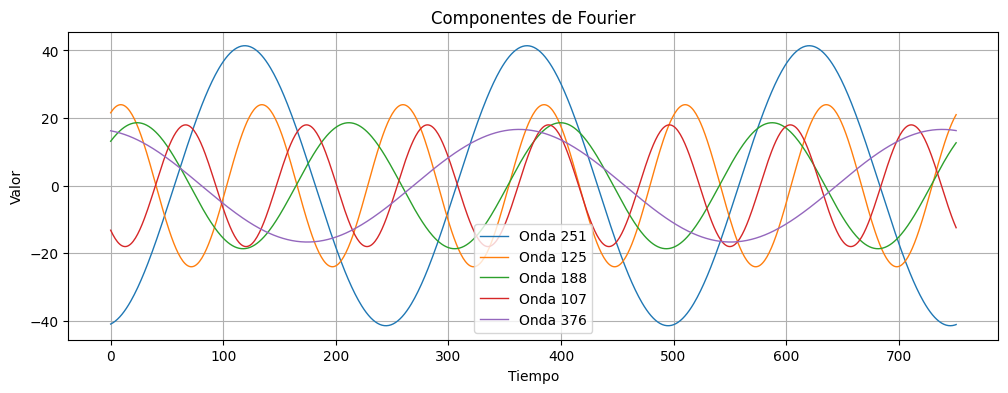

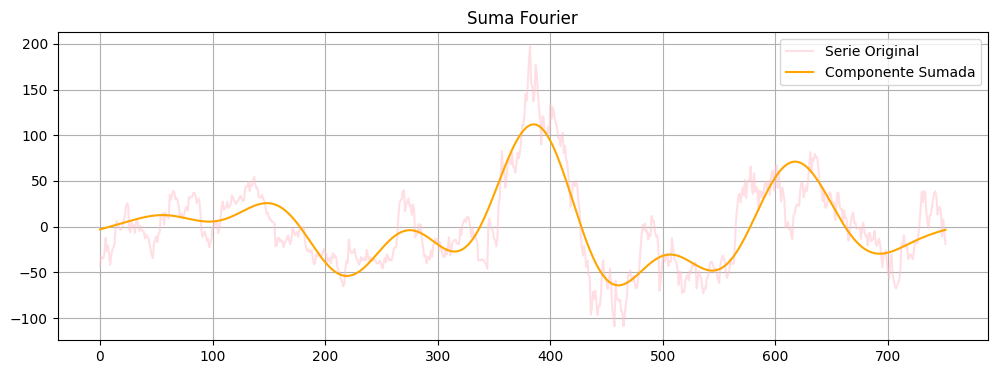

In [15]:
serie = df["ruido_polinomial"].values

terminos = 5

un_grafico = False

cts = Transformada_de_Fourier(
    serie,
    terminos,
    un_grafico
)

df["estacionalidad_polinomial"]= cts

In [16]:
df["ruido_final"] = (
    df["Adj_Close_TSLA"]
    - df["tendencia_polinomial"]
    - df["estacionalidad_polinomial"]
)

df.head()

,Fecha,Adj_Close_TSLA,tendencia_polinomial,ruido_polinomial,estacionalidad_polinomial,ruido_final
0,2023-06-12,249.830002,292.689045,-42.859043,-3.105270,-39.753773
1,2023-06-13,258.709991,291.947358,-33.237367,-2.760930,-30.476437
2,2023-06-14,256.790009,291.208946,-34.418938,-2.418753,-32.000185
3,2023-06-15,255.899994,290.473808,-34.573814,-2.078205,-32.495609
4,2023-06-16,260.540009,289.741942,-29.201933,-1.738777,-27.463156


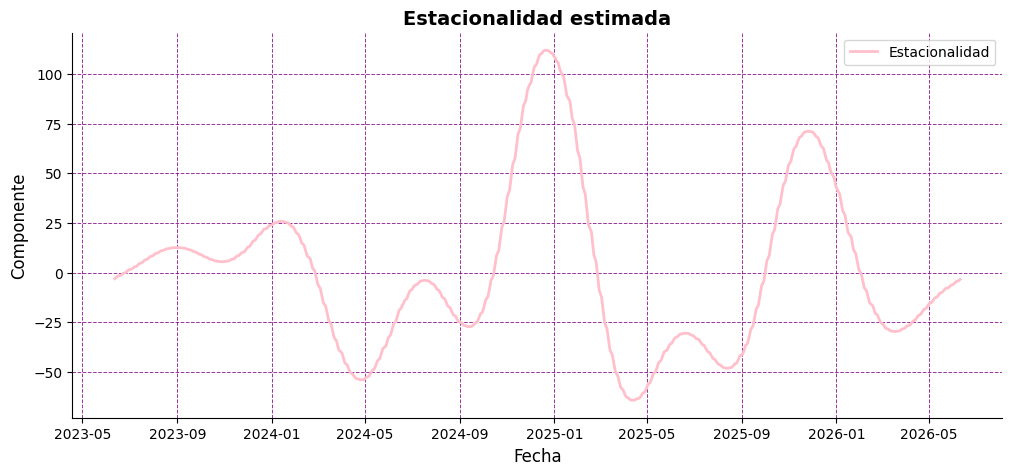

In [17]:
plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    df["estacionalidad_polinomial"],
    color="pink",
    linewidth=2,
    label="Estacionalidad"
)

plt.title(
    "Estacionalidad estimada",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Componente", fontsize=12)

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
    color="purple"
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.margins(x=0.05, y=0.05)

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.legend(fontsize=10, loc='best', frameon=True)

plt.show()

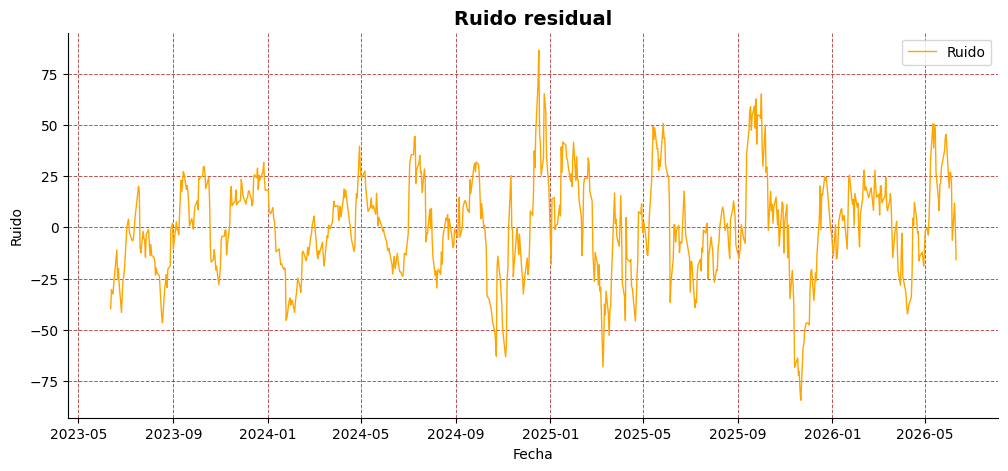

In [18]:
plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    df["ruido_final"],
    color="orange",
    linewidth=1,
    label="Ruido"
)

plt.title(
    "Ruido residual",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fecha")
plt.ylabel("Ruido")

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
    color="brown"
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.margins(x=0.05, y=0.05)

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.legend(fontsize=10, loc='best', frameon=True)
plt.show()

In [19]:
serie_aproximada= (
    df["tendencia_polinomial"]
    + df["estacionalidad_polinomial"]
    + df["ruido_final"]
)


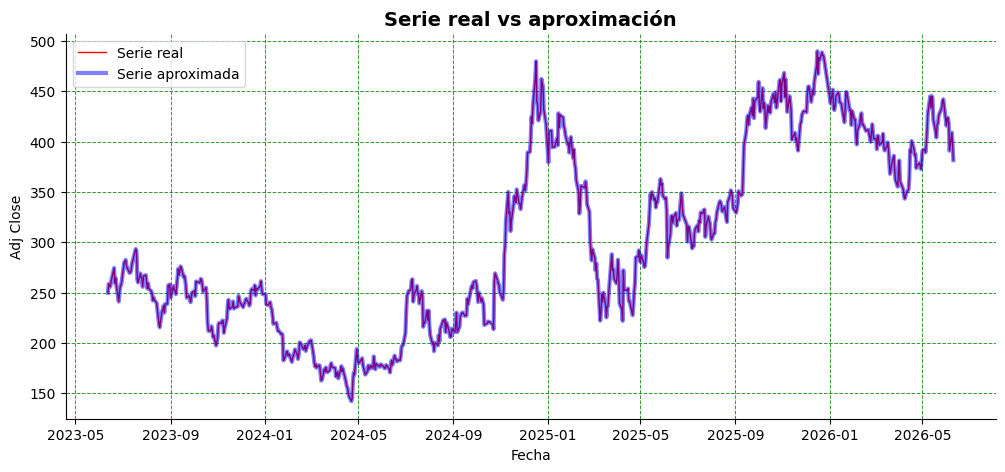

In [20]:
plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    df["Adj_Close_TSLA"],
    color="red",
    linewidth=1,
    label="Serie real"
)

plt.plot(
    x,
    serie_aproximada,
    color="blue",
    linewidth=3,
    alpha=0.5,
    label="Serie aproximada"
)

plt.title(
    "Serie real vs aproximación",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fecha")
plt.ylabel("Adj Close")

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
    color="green"
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.margins(x=0.05, y=0.05)

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.legend(fontsize=10, loc='best', frameon=True)
plt.show()

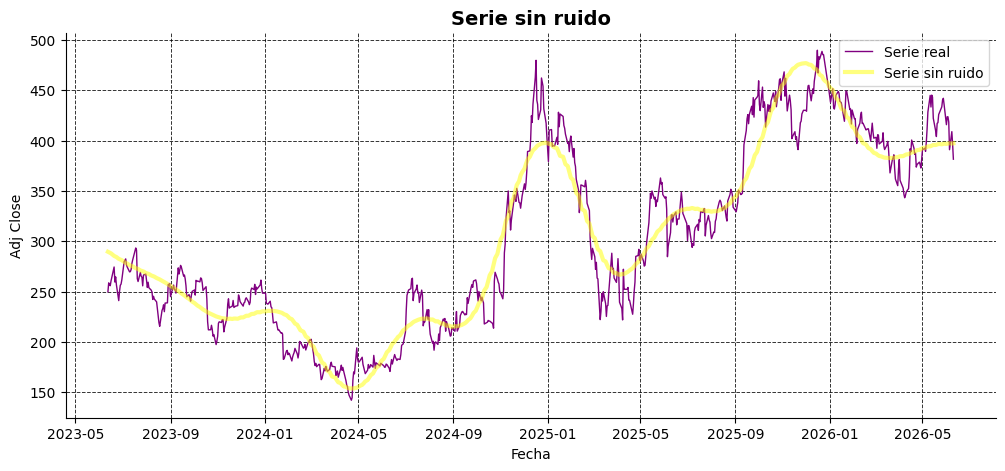

In [21]:
serie_sin_ruido = (
    df["tendencia_polinomial"]
    + df["estacionalidad_polinomial"]
)

plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    df["Adj_Close_TSLA"],
    color="purple",
    linewidth=1,
    label="Serie real"
)

plt.plot(
    x,
    serie_sin_ruido,
    color="yellow",
    linewidth=3,
    alpha=0.5,
    label="Serie sin ruido"
)

plt.title(
    "Serie sin ruido",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fecha")
plt.ylabel("Adj Close")

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
    color="black"
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.margins(x=0.05, y=0.05)

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.legend(fontsize=10, loc='best', frameon=True)
plt.show()

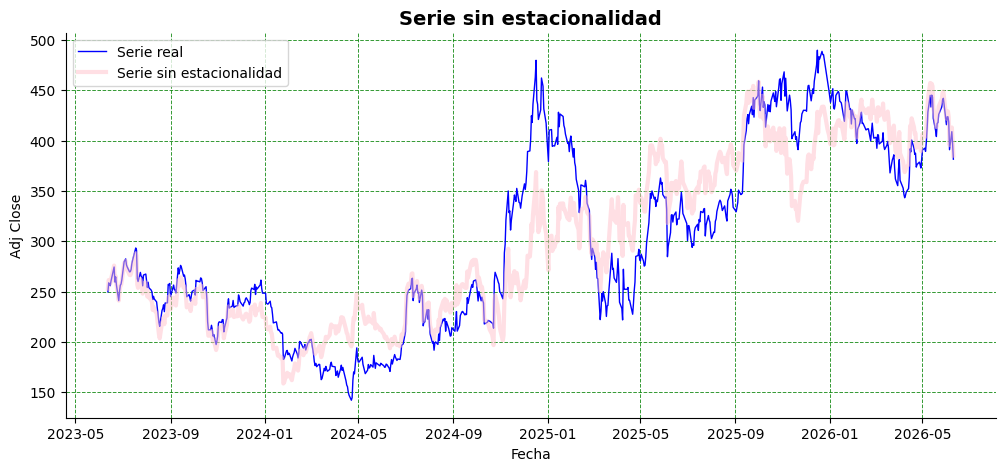

In [22]:
serie_sin_estacionalidad = (
    df["tendencia_polinomial"]
    + df["ruido_final"]
)

plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    df["Adj_Close_TSLA"],
    color="blue",
    linewidth=1,
    label="Serie real"
)

plt.plot(
    x,
    serie_sin_estacionalidad,
    color="pink",
    linewidth=3,
    alpha=0.5,
    label="Serie sin estacionalidad"
)

plt.title(
    "Serie sin estacionalidad",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fecha")
plt.ylabel("Adj Close")

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
    color="green"
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.margins(x=0.05, y=0.05)

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.legend(fontsize=10, loc='best', frameon=True)
plt.show()

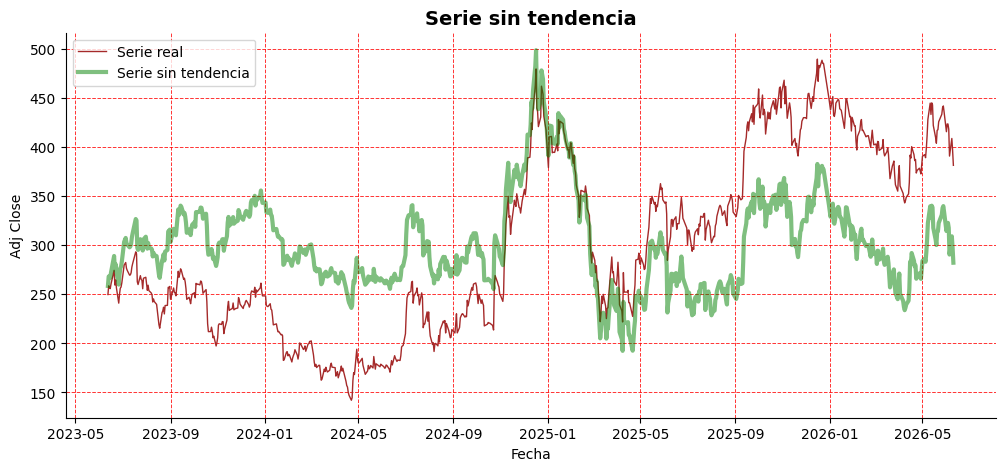

In [23]:
serie_sin_tendencia = (
    df["estacionalidad_polinomial"]
    + df["ruido_final"]
    + df["Adj_Close_TSLA"].mean()
)

plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    df["Adj_Close_TSLA"],
    color="brown",
    linewidth=1,
    label="Serie real"
)

plt.plot(
    x,
    serie_sin_tendencia,
    color="green",
    linewidth=3,
    alpha=0.5,
    label="Serie sin tendencia"
)

plt.title(
    "Serie sin tendencia",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fecha")
plt.ylabel("Adj Close")

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
    color="red"
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.margins(x=0.05, y=0.05)

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.legend(fontsize=10, loc='best', frameon=True)
plt.show()

Serie de tiempo Tesla:
En la gráfica se puede ver que el precio de Tesla cambia mucho durante el tiempo analizado. Hay momentos donde el valor de la acción sube rápido y otros donde baja de manera considerable. Esto demuestra que el precio de Tesla es muy cambiante y puede verse afectado por distintos factores económicos y financieros.

Tendencia polinomial Tesla:
La gráfica de tendencia polinomial muestra una línea más uniforme que la serie original. Esto ayuda a observar mejor cómo ha sido el comportamiento general del precio con el paso del tiempo, identificando etapas donde el valor aumenta y otras donde disminuye.

Componentes de Fourier:
En esta gráfica aparecen varias ondas que representan patrones encontrados en la serie temporal. Algunas tienen movimientos más grandes y otras más pequeños, lo que indica que existen ciclos que se repiten en diferentes periodos dentro del comportamiento del precio de Tesla.

Estacionalidad estimada:
La gráfica de estacionalidad permite observar ciertos movimientos que se repiten constantemente. Se pueden notar subidas y bajadas que siguen un comportamiento parecido en distintos momentos, lo cual indica que hay ciclos que afectan el comportamiento de la serie.

Ruido residual:
La gráfica del ruido residual muestra cambios muy desordenados y sin un patrón claro. Hay aumentos y disminuciones repentinas, lo que representa factores aleatorios que no se explican por la tendencia ni por la estacionalidad.

Serie real vs aproximación:
En esta comparación se observa que la serie original y la aproximada son bastante parecidas durante casi todo el periodo estudiado. Esto significa que el modelo utilizado logra representar de buena forma gran parte del comportamiento del precio de Tesla.

Serie sin ruido:
Al eliminar el ruido, la gráfica se ve más estable y fácil de entender. Los movimientos bruscos disminuyen y esto ayuda a identificar mejor el comportamiento general y las tendencias del precio.

Serie sin estacionalidad:
En esta gráfica ya no se observan algunos movimientos repetitivos, por lo que la serie parece más uniforme. Aunque todavía existen cambios en el precio, resulta más sencillo notar otros factores que influyen en el comportamiento de la acción.

Serie sin tendencia:
Cuando se elimina la tendencia, la serie deja de mostrar el comportamiento general a largo plazo y se enfoca más en los cambios pequeños y variaciones temporales del precio.

Conclusión:
Después de analizar las gráficas, se pudo notar que el precio de Tesla tiene muchos cambios y variaciones durante el periodo estudiado. Algunas gráficas ayudaron a entender mejor cómo se comporta el precio con el tiempo, mientras que otras permitieron identificar ciclos, patrones repetitivos y cambios aleatorios. Además, al comparar la serie real con la aproximación se observó que el modelo representa bastante bien el comportamiento general de la acción. En general, esta práctica ayudó a comprender mejor cómo funcionan las series de tiempo y cómo pueden utilizarse para analizar datos financieros como el precio de Tesla.